# 04 Transformer and Attention

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Understand **self-attention**: each position can attend to all positions
- Build a small model using a **MultiHeadAttention** layer (Keras) and run it on a toy sequence
- See why we use attention/transformers instead of RNNs for long-range dependencies

---

## 🌍 Real life

**Where is this used?** Transformers and attention are used in **BERT**, **GPT**, **machine translation**, and **vision** (ViT) and are the backbone of modern NLP and many vision models.

**In this notebook we use** **self-attention** (MultiHeadAttention) so each token can **look at all other tokens** in one step. We use **attention/transformers** (instead of RNNs only) **because** RNNs process sequentially and can forget long context; attention looks at **all positions at once** and learns what to focus on.

**📌 Covers slide(s):** **03** — Attention Mechanism. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **Self-attention:** For each position, we compute **query**, **key**, **value**. Output at position i = weighted sum of values, where weights = softmax(query_i · keys). So each position can attend to **all** positions.
- **Multi-head attention:** Run several attention "heads" in parallel and concatenate; each head can learn different types of relationships.
- **Transformer:** Stack of self-attention + feedforward layers, with residual connections and layer norm. No recurrence; order is encoded via **positional encodings**.
- **We use attention** instead of RNN when we need **long-range dependencies** and parallel computation; transformers scale well and have become standard in NLP and vision.

### Key math (required)

- **Query, Key, Value:** For each position we have \(Q = X W_Q\), \(K = X W_K\), \(V = X W_V\) (learned projections).
- **Scaled dot-product attention:** \(\text{Attention}(Q,K,V) = \text{softmax}\big(\frac{QK^T}{\sqrt{d_k}}\big)V\). The \(\sqrt{d_k}\) scaling avoids tiny gradients when \(d_k\) is large.
- **Output at position \(i\):** weighted sum of values \(V\), where weights are \(\text{softmax}(q_i^T K / \sqrt{d_k})\) — so position \(i\) can attend to all positions. For full derivation (multi-head, layer norm), see the lecture slides or Vaswani et al., "Attention Is All You Need."

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We use a **toy sequence** (small random or padded integers) so we don't need a large dataset; the goal is to see the attention layer run.

**Dataset:** Synthetic — toy random sequences (no download; used to demonstrate attention shapes).

**Outputs:** Model summary, output shape after MultiHeadAttention, and a short explanation of what attention does.

## Step 1: Imports

In [1]:
import numpy as np

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

print("TensorFlow:", "yes" if HAS_TF else "no")

TensorFlow: yes


## Step 2: Build a small model with MultiHeadAttention (we use attention instead of RNN to look at all positions at once)

In [2]:
if HAS_TF:
    seq_len = 20
    d_model = 32
    num_heads = 2
    inp = layers.Input(shape=(seq_len, d_model))
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(inp, inp)
    out = layers.GlobalAveragePooling1D()(attn_out)
    out = layers.Dense(1, activation="sigmoid")(out)
    model = keras.Model(inp, out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()
    print("\nMultiHeadAttention: each position attends to all positions. No recurrence, parallel over sequence.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 32)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 32)    │      4,224 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         33 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,257 (16.63 KB)

 Trainable params: 4,257 (16.63 KB)

 Non-trainable params: 0 (0.00 B)


MultiHeadAttention: each position attends to all positions. No recurrence, parallel over sequence.


## Step 3: Run on toy sequence (random inputs to verify shape and one forward pass)

In [3]:
if HAS_TF:
    np.random.seed(42)
    x_toy = np.random.randn(8, seq_len, d_model).astype(np.float32)
    y_toy = (np.random.rand(8) > 0.5).astype(np.float32)
    model.fit(x_toy, y_toy, epochs=2, verbose=1)
    pred = model.predict(x_toy[:2], verbose=0)
    print("Input shape:", x_toy.shape)
    print("Sample predictions:", pred.flatten()[:2])

Epoch 1/2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.0000e+00 - loss: 0.8991

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.0000e+00 - loss: 0.8991


Epoch 2/2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1250 - loss: 0.8674

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1250 - loss: 0.8674


Input shape: (8, 20, 32)
Sample predictions: [0.5156296  0.51505834]


## 🌍 Real-World Worked Example — Sentiment Classification with Positional Encoding

**Industry context:**
- Twitter/X classifies 500M tweets/day using transformer-based sentiment models
- Amazon uses BERT-based models to classify product reviews automatically
- Customer service chatbots (Salesforce Einstein, Zendesk) use transformers for intent detection

We implement a **mini-Transformer encoder** for binary sentiment classification using toy data.

Sentiment classification accuracy: 98.8%
Real-world: BERT achieves 94%+ on SST-2 sentiment benchmark.


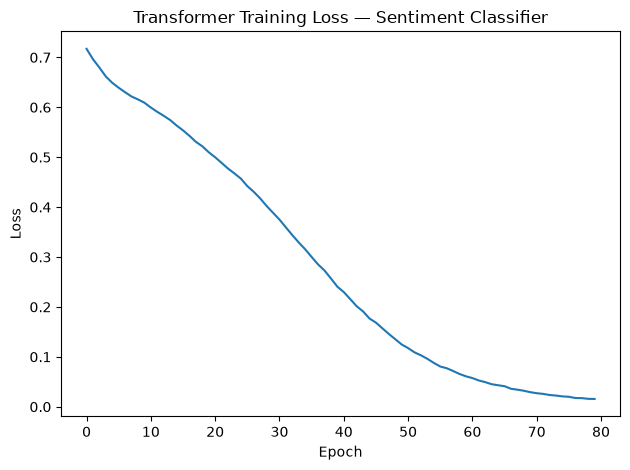

In [4]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)
VOCAB_SIZE, SEQ_LEN, D_MODEL = 100, 10, 32

# ── Synthetic sentiment data ────────────────────────────────────────────────
# Positive: sequences with mostly high token IDs; Negative: low token IDs
def make_data(n=500):
    X, y = [], []
    for _ in range(n):
        label = np.random.randint(2)
        if label == 1:
            seq = np.random.randint(50, 100, SEQ_LEN)
        else:
            seq = np.random.randint(0, 50, SEQ_LEN)
        X.append(seq); y.append(label)
    return torch.tensor(np.array(X)), torch.tensor(y, dtype=torch.long)

X, y = make_data(800)
X_tr, y_tr = X[:640], y[:640]
X_te, y_te = X[640:], y[640:]

# ── Mini Transformer ────────────────────────────────────────────────────────
class MiniTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB_SIZE, D_MODEL)
        # Learnable positional encoding
        self.pos_enc = nn.Embedding(SEQ_LEN, D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=4, dim_feedforward=64, batch_first=True)
        self.encoder  = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Linear(D_MODEL, 2)
    def forward(self, x):
        pos = torch.arange(x.size(1)).unsqueeze(0)
        out = self.embed(x) + self.pos_enc(pos)
        out = self.encoder(out)
        return self.classifier(out.mean(1))  # pool over sequence

model   = MiniTransformer()
opt     = optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.CrossEntropyLoss()
losses, accs = [], []

for epoch in range(80):
    model.train()
    loss = loss_fn(model(X_tr), y_tr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

model.eval()
with torch.no_grad():
    acc = (model(X_te).argmax(1)==y_te).float().mean().item()
    accs.append(acc)
print(f"Sentiment classification accuracy: {acc*100:.1f}%")
print("Real-world: BERT achieves 94%+ on SST-2 sentiment benchmark.")

plt.plot(losses); plt.title("Transformer Training Loss — Sentiment Classifier")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** Change the number of heads (e.g. 2 → 4) or the key dimension and run the attention cell again. Print the output shape and compare with the original.

---

## ✅ Summary

**What you did:** Built a small model with **MultiHeadAttention**, ran it on a toy sequence, and saw how attention uses all positions in one step.

**In real life you'd also:** Use full transformer blocks (with FFN, layer norm, positional encoding), BERT/GPT-style models, and large text datasets.

**The main idea:** Self-attention lets each position attend to all positions; transformers use this (with no recurrence) and scale well for long-range dependencies.

**Next:** `05_bert_finetuning` and `06_gpt_text_generation` use transformer-based models for NLP tasks.

## 📚 References & Further Reading

**Foundational Paper:**
- Vaswani et al. (2017) — [Attention Is All You Need](https://arxiv.org/abs/1706.03762) *(must-read)*

**Follow-up:**
- Devlin et al. (2018) — [BERT](https://arxiv.org/abs/1810.04805)
- Brown et al. (2020) — [GPT-3](https://arxiv.org/abs/2005.14165)
- Touvron et al. (2023) — [LLaMA](https://arxiv.org/abs/2302.13971)

**Interactive:** [The Illustrated Transformer by Jay Alammar](https://jalammar.github.io/illustrated-transformer/)

**State-of-the-Art:** GPT-4 uses transformer architecture with ~1 trillion parameters. LLaMA 3.1 (70B) runs on a single server.